# Q11.
```{admonition}
:class: note
In Section 7.7, it was mentioned that GAMs are generally fit using a *backfitting* approach. The idea behind backfitting is actually quite simple. We will now explore backfitting in the context of multiple linear regression.
    
    
Suppose that we would like to perform multiple linear regression, but we do not have software to do so. Instead, we only have software to perform simple linear regression. Therefore, we take the following iterative approach: we repeatedly hold all but one coefficient estimate fixed at its current value, and update only that coefficient estimate using a simple linear regression. The process is continued until *convergence*—that is, until the coefficient estimates stop changing.

We now try this out on a toy example.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## (a)
```{admonition}
:class: note
Generate a response $Y$ and two predictors $X_{1}$ and $X_{2}$, with $n=100$.

In [4]:
rng = np.random.default_rng(1728)
X1, X2 = rng.normal(size=100),rng.normal(size=100)
Y = 1-2*X1+3*X2+rng.normal(size=100)

## (b)
```{admonition}
:class: note
Write a function `simple_reg()` that takes two arguments `outcome` and `feature`, and returns the estimated intercept and slope.

In [5]:
def simple_reg(outcome,feature):
    lr = np.polyfit(outcome,feature,1)
    return lr[1],lr[0]

## (c)
```{admonition}
:class: note
Initialize `beta1` to take on a value of your choice.

In [6]:
beta1 = 5

## (d)
```{admonition}
:class: note
Keeping `beta1` fixed, use your function `simple_reg()` to fit the model:
    $$
    Y - \textcolor{pink}{\text{beta1}} \cdot X_{1} = \beta_{0}+\beta_{2}X_{2}+\varepsilon.
    $$
    Store the resulting values as `beta0` and `beta2`.

In [7]:
beta0, beta2 = simple_reg(X2,Y-beta1*X1)

## (e)
```{admonition}
:class: note
Keeping `beta2` fixed, use your function `simple_reg()` to fit the model:
    $$
    Y - \textcolor{pink}{\text{beta2}} \cdot X_{2} = \beta_{0}+\beta_{1}X_{1}+\varepsilon.
    $$
    Store the resulting values as `beta0` and `beta1`.

In [8]:
beta0, beta1 = simple_reg(X1,Y-beta2*X2)

## (f)
```{admonition}
:class: note
Write a for loop to repeat (d) and (e) 1 000 times. Report the estimates of `beta0`, `beta1`, and `beta2` at each interation of the for loop. Create a plot in which each of these values is displayed with `beta0`, `beta1`, `beta2`.

Model coefficients at iteration 0: 1.1034812935300407,-1.9814898336607523,2.9427922549074315
Model coefficients at iteration 1: 1.103736924554665,-1.9815967725539099,2.9407839493055468
Model coefficients at iteration 2: 1.1037379269919443,-1.9815971919065032,2.940776073890557
Model coefficients at iteration 3: 1.1037379309229247,-1.9815971935509618,2.9407760430077263
Model coefficients at iteration 4: 1.1037379309383395,-1.9815971935574104,2.9407760428866205
Model coefficients at iteration 5: 1.1037379309384,-1.9815971935574361,2.940776042886147
Model coefficients at iteration 6: 1.1037379309384006,-1.9815971935574361,2.940776042886145
Model coefficients at iteration 7: 1.1037379309384006,-1.9815971935574361,2.940776042886145
Model coefficients at iteration 8: 1.1037379309384006,-1.9815971935574361,2.940776042886145
Model coefficients at iteration 9: 1.1037379309384006,-1.9815971935574361,2.940776042886145
Model coefficients at iteration 10: 1.1037379309384006,-1.9815971935574361,2.940

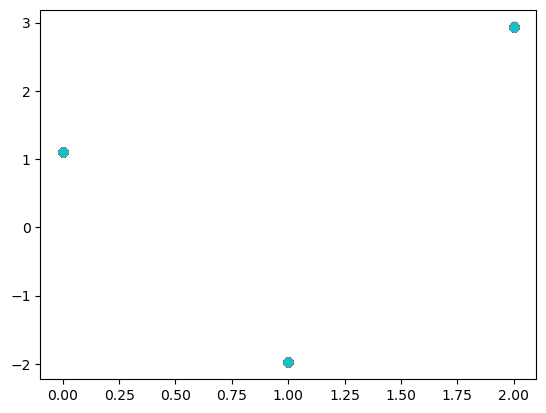

In [9]:
iteration = {}
for i in range(1000):
    beta0, beta2 = simple_reg(X2,Y-beta1*X1)
    beta0, beta1 = simple_reg(X1,Y-beta2*X2)
    iteration[i] = [beta0,beta1,beta2]
    plt.scatter([0,1,2],iteration[i])
    print(f'Model coefficients at iteration {i}: {beta0},{beta1},{beta2}')

## (g)
```{admonition}
:class: note
Compare your answer in (e) to the results of simply performing multiple linear regression to predict $Y$ using $X_{1}$ and $X_{2}$.

In [10]:
B = np.array([1,-2,3])
X = np.column_stack([np.ones(100),X1,X2])
o,*_ = np.linalg.lstsq(X,Y)
print(o,iteration[999])

[ 1.10373793 -1.98159719  2.94077604] [np.float64(1.1037379309384006), np.float64(-1.9815971935574361), np.float64(2.940776042886145)]


## (h)
```{admonition}
:class: note
On this data set, how many backfitting iterations were required in order to obtain a “good” approximation to the multiple regression coefficient estimates?

In [11]:
for i in range(6):
    print('Ratio of iteration to multilinear fit:', iteration[i]/o)

Ratio of iteration to multilinear fit: [0.99976748 0.99994582 1.00068561]
Ratio of iteration to multilinear fit: [0.99999909 0.99999979 1.00000269]
Ratio of iteration to multilinear fit: [1.         1.         1.00000001]
Ratio of iteration to multilinear fit: [1. 1. 1.]
Ratio of iteration to multilinear fit: [1. 1. 1.]
Ratio of iteration to multilinear fit: [1. 1. 1.]
